In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')


In [17]:
df=pd.read_csv("/content/drive/MyDrive/Machine Learning - 1/Insurance_dataset.csv")

In [18]:
df.head()

,Age,BMI,Smoker,Number_of_Children,Gender,Region,Insurance_Cost
0,56,19.0,no,3,male,southwest,1601.28
1,69,28.0,no,3,male,northwest,2900.81
2,46,23.2,no,3,female,southwest,2249.51
3,32,19.9,no,2,male,southeast,1662.48
4,60,23.8,no,3,male,southwest,2149.76


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1000 non-null   int64  
 1   BMI                 1000 non-null   float64
 2   Smoker              1000 non-null   object 
 3   Number_of_Children  1000 non-null   int64  
 4   Gender              1000 non-null   object 
 5   Region              1000 non-null   object 
 6   Insurance_Cost      1000 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 54.8+ KB


In [20]:
df.describe()

,Age,BMI,Number_of_Children,Insurance_Cost
count,1000.00000,1000.000000,1000.000000,1000.00000
mean,43.81900,27.288100,1.966000,3888.04372
std,14.99103,4.941707,1.416634,4072.35034
min,18.00000,12.500000,0.000000,-384.27000
25%,31.00000,23.900000,1.000000,1558.01500
50%,44.00000,27.300000,2.000000,2102.80500
75%,56.00000,30.425000,3.000000,2984.06750
max,69.00000,40.200000,4.000000,13461.33000


In [21]:
df.isnull().sum()

,0
Age,0
BMI,0
Smoker,0
Number_of_Children,0
Gender,0
Region,0
Insurance_Cost,0


In [22]:
# So there are no null values here

In [80]:
df[df["Insurance_Cost"]<0]["Insurance_Cost"]

,Insurance_Cost
833,-22.88
855,-54.89
912,-384.27
921,-132.14


In [23]:
#Converting categorical columns to numeric data type
#gender Male female as 1 and 0
#wile smoking as 1 nonsmoking as 0

In [24]:
df["Gender"]=df["Gender"].apply(lambda x:1 if x=="Male" else 0)
df["Smoker"]=df["Smoker"].apply(lambda x:1 if x=="Yes" else 0)

In [25]:
df.head()

,Age,BMI,Smoker,Number_of_Children,Gender,Region,Insurance_Cost
0,56,19.0,0,3,0,southwest,1601.28
1,69,28.0,0,3,0,northwest,2900.81
2,46,23.2,0,3,0,southwest,2249.51
3,32,19.9,0,2,0,southeast,1662.48
4,60,23.8,0,3,0,southwest,2149.76


<Axes: xlabel='Age', ylabel='Insurance_Cost'>

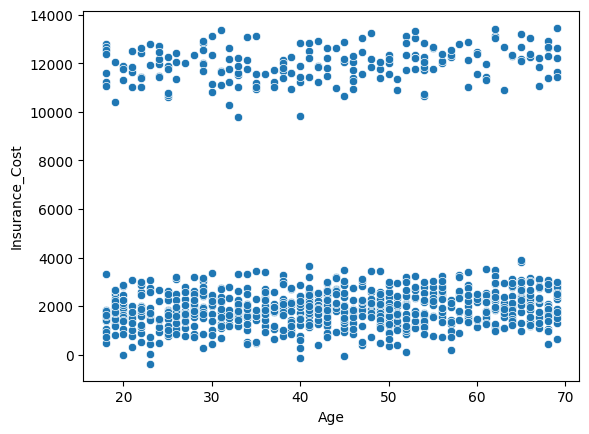

In [36]:
#checking scatter plots to see the relation
sns.scatterplot(data=df,x="Age",y="Insurance_Cost")


<Axes: xlabel='BMI', ylabel='Insurance_Cost'>

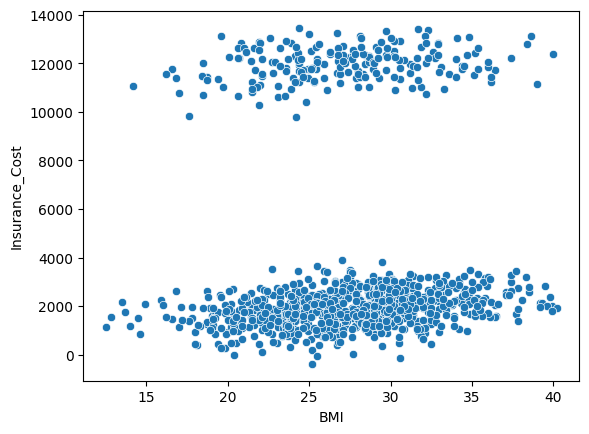

In [37]:
sns.scatterplot(data=df,x="BMI",y="Insurance_Cost")

<Axes: xlabel='Smoker', ylabel='Insurance_Cost'>

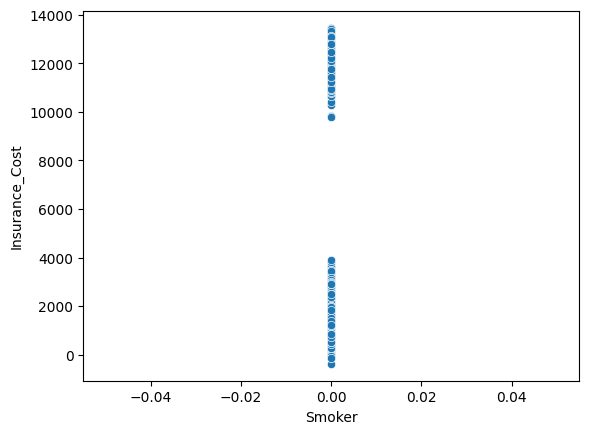

In [38]:
sns.scatterplot(data=df,x="Smoker",y="Insurance_Cost")

<Axes: xlabel='Number_of_Children', ylabel='Insurance_Cost'>

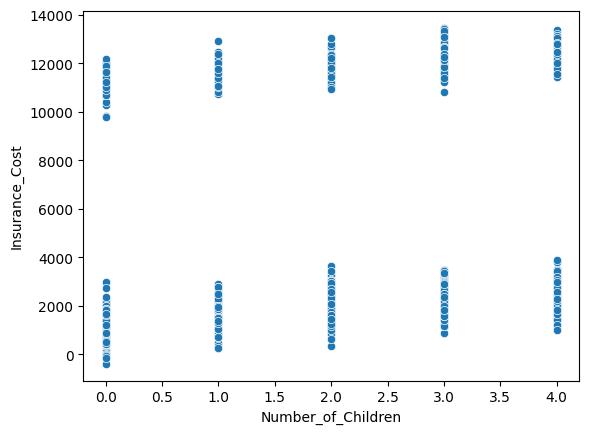

In [39]:
sns.scatterplot(data=df,x="Number_of_Children",y="Insurance_Cost")

<Axes: xlabel='Gender', ylabel='Insurance_Cost'>

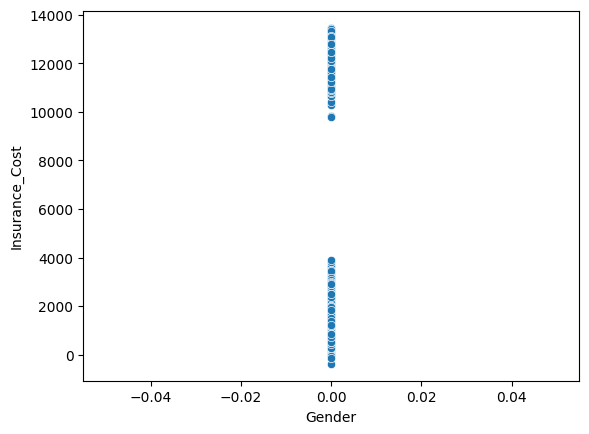

In [40]:
sns.scatterplot(data=df,x="Gender",y="Insurance_Cost")

In [ ]:
#Encoding the data

In [75]:
X=df[["Age", "BMI", "Smoker", "Number_of_Children",	"Gender"]]
y=df['Insurance_Cost']

In [76]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [77]:
#Applying polynomial transformation

In [78]:
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [79]:
reg=LinearRegression()
reg.fit(X_train_poly,y_train)
y_pred=reg.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

-0.025244257070405673
